# EDA 
## 1. Load Processed Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sales = pd.read_csv("../data/processed/sales_daily.csv")
sku_master = pd.read_csv("../data/processed/sku_master.csv")
calendar = pd.read_csv("../data/processed/calendar.csv")
inventory = pd.read_csv("../data/processed/inventory_snapshots.csv")

sales["date"] = pd.to_datetime(sales["date"])
inventory["date"] = pd.to_datetime(inventory["date"])
calendar["date"] = pd.to_datetime(calendar["date"])

print("Sales:", sales.shape)
print("SKU Master:", sku_master.shape)
print("Calendar:", calendar.shape)
print("Inventory:", inventory.shape)

Sales: (73100, 7)
SKU Master: (100, 3)
Calendar: (731, 3)
Inventory: (73100, 4)


## 2. Demand Distribution Analysis

In [2]:
sales["units_sold"].describe()

count    73100.000000
mean       136.464870
std        108.919406
min          0.000000
25%         49.000000
50%        107.000000
75%        203.000000
max        499.000000
Name: units_sold, dtype: float64

### 2.1 Demand Distribution Plot

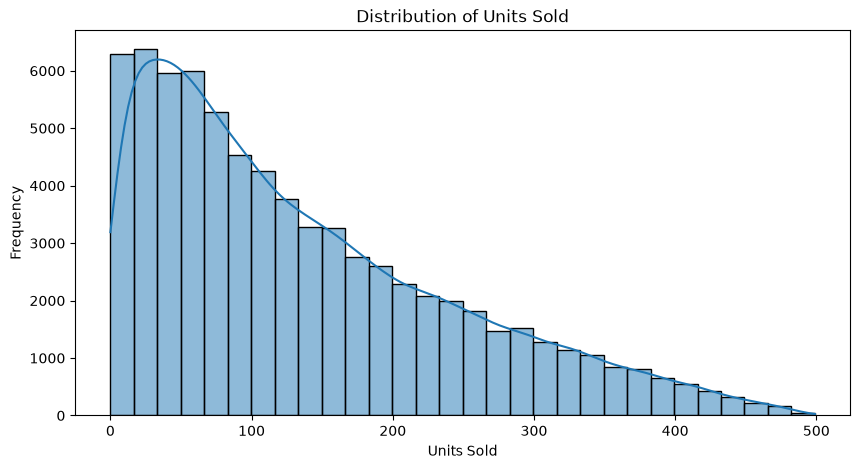

In [3]:
plt.figure(figsize=(10, 5))

sns.histplot(
    sales["units_sold"],
    bins=30,
    kde=True
)

plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.show()

### 2.2 Zero Sales Analysis

In [4]:
zero_sales = (sales["units_sold"] == 0).sum()
total_sales_records = len(sales)

print("Zero-sales records:", zero_sales)
print("Total records:", total_sales_records)
print("Zero-sales percentage:", round(zero_sales / total_sales_records * 100, 2), "%")

Zero-sales records: 360
Total records: 73100
Zero-sales percentage: 0.49 %


### Top 10 SKUs by Total Sales

In [5]:
top_movers = (
    sales.groupby("sku_id")["units_sold"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_movers

sku_id
S005_P0015    109099
S003_P0013    107479
S002_P0001    105999
S005_P0003    105667
S003_P0005    105408
S002_P0009    105376
S002_P0020    105343
S003_P0014    105188
S004_P0016    104777
S003_P0017    104566
Name: units_sold, dtype: int64

### Top 10 SKUs Visualization

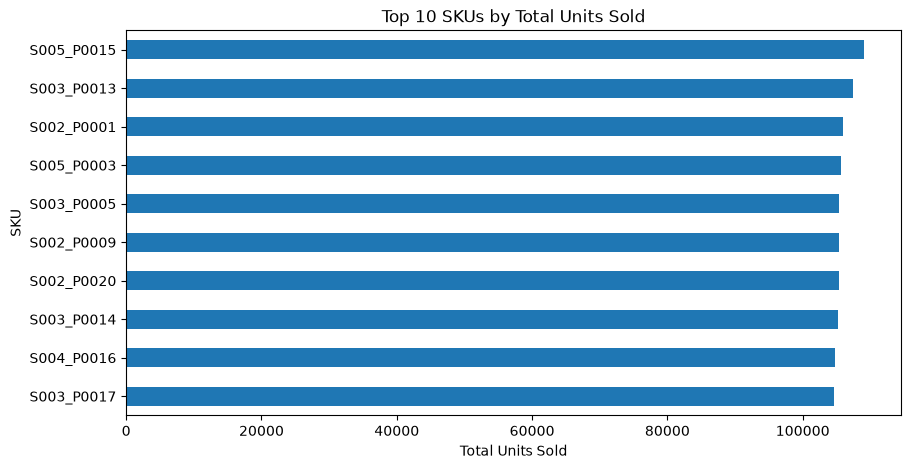

In [6]:
plt.figure(figsize=(10, 5))

top_movers.sort_values().plot(kind="barh")

plt.title("Top 10 SKUs by Total Units Sold")
plt.xlabel("Total Units Sold")
plt.ylabel("SKU")
plt.show()

### Top 10 Sales Contribution

In [7]:
total_units = sales["units_sold"].sum()
top_10_units = top_movers.sum()

contribution = (top_10_units / total_units) * 100

print("Total units sold:", total_units)
print("Top 10 units sold:", top_10_units)
print("Top 10 contribution:", round(contribution, 2), "%")

Total units sold: 9975582
Top 10 units sold: 1058902
Top 10 contribution: 10.61 %


##  Dead Stock Analysis

In [8]:
sku_zero_sales = (
    sales.groupby("sku_id")["units_sold"]
    .sum()
    .sort_values()
)

sku_zero_sales.head(10)

sku_id
S003_P0003    92556
S001_P0012    93854
S004_P0018    94023
S002_P0002    94143
S002_P0008    94225
S004_P0003    94436
S003_P0001    94620
S004_P0007    95309
S004_P0002    95358
S001_P0006    95522
Name: units_sold, dtype: int64

## Dead Stock Analysis

In [9]:
zero_sales_days = (
    sales.groupby("sku_id")["units_sold"]
    .apply(lambda x: (x == 0).sum())
    .sort_values(ascending=False)
)

zero_sales_days.head(10)

sku_id
S001_P0010    8
S004_P0004    8
S002_P0018    8
S002_P0017    8
S003_P0015    8
S004_P0020    7
S004_P0007    7
S003_P0010    7
S001_P0019    6
S004_P0005    6
Name: units_sold, dtype: int64

## Zero-Sales Days Visualization

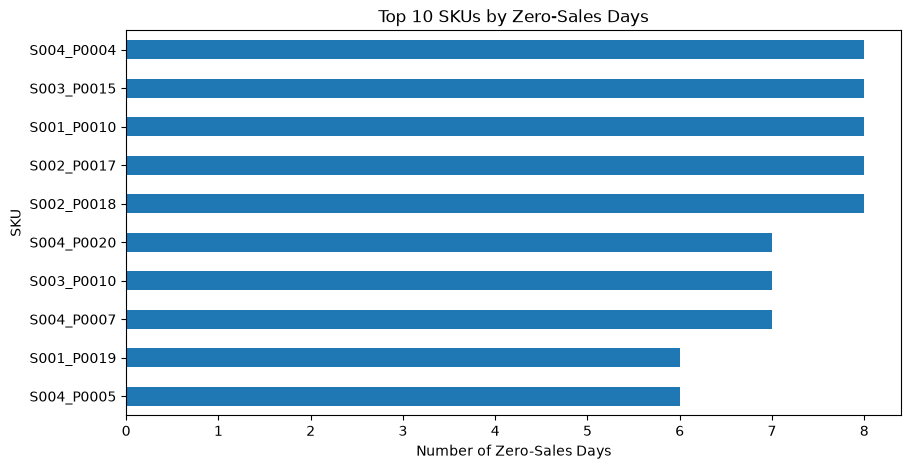

In [10]:
plt.figure(figsize=(10, 5))

zero_sales_days.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 SKUs by Zero-Sales Days")
plt.xlabel("Number of Zero-Sales Days")
plt.ylabel("SKU")
plt.show()

##  Dead Stock Summary

In [11]:
print("SKUs with at least one zero-sales day:", (zero_sales_days > 0).sum())
print("Maximum zero-sales days for a SKU:", zero_sales_days.max())
print("SKUs with zero total sales:", (sku_zero_sales == 0).sum())

SKUs with at least one zero-sales day: 97
Maximum zero-sales days for a SKU: 8
SKUs with zero total sales: 0


## Correlation Analysis

In [12]:
corr_cols = [
    "units_sold",
    "revenue",
    "unit_price",
    "discount_pct",
    "promo_flag"
]

correlation = sales[corr_cols].corr()

correlation

,units_sold,revenue,unit_price,discount_pct,promo_flag
units_sold,1.000000,0.793865,0.001082,0.002576,-0.000374
revenue,0.793865,1.000000,0.468666,-0.073643,0.000282
unit_price,0.001082,0.468666,1.000000,0.001509,0.002309
discount_pct,0.002576,-0.073643,0.001509,1.000000,-0.000852
promo_flag,-0.000374,0.000282,0.002309,-0.000852,1.000000


## Correlation Heatmap

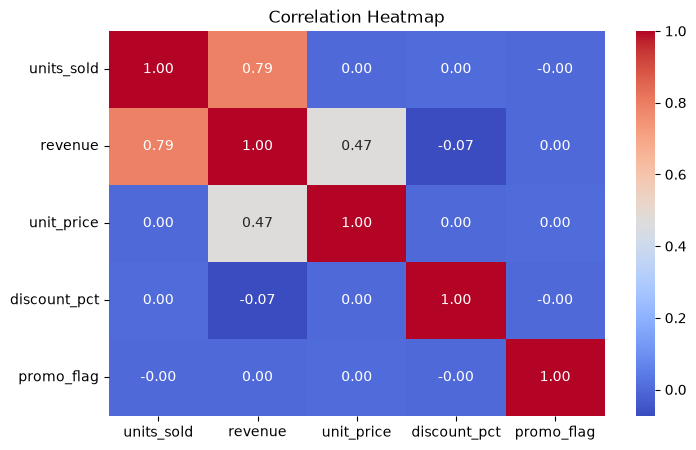

In [13]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

## Correlation Insights

In [14]:
print("Correlation with units_sold:")
print(correlation["units_sold"].sort_values(ascending=False))

Correlation with units_sold:
units_sold      1.000000
revenue         0.793865
discount_pct    0.002576
unit_price      0.001082
promo_flag     -0.000374
Name: units_sold, dtype: float64


## Seasonality & Driver Analysis

In [15]:
sales["month"] = sales["date"].dt.month
sales["year"] = sales["date"].dt.year

monthly_demand = (
    sales.groupby(["year", "month"])["units_sold"]
    .sum()
    .reset_index()
)

monthly_demand

,year,month,units_sold
0,2022,1,419938
1,2022,2,391052
2,2022,3,426073
3,2022,4,407380
4,2022,5,414799
5,2022,6,415509
6,2022,7,426628
7,2022,8,424916
8,2022,9,411610
9,2022,10,426863


## Monthly Demand Trend

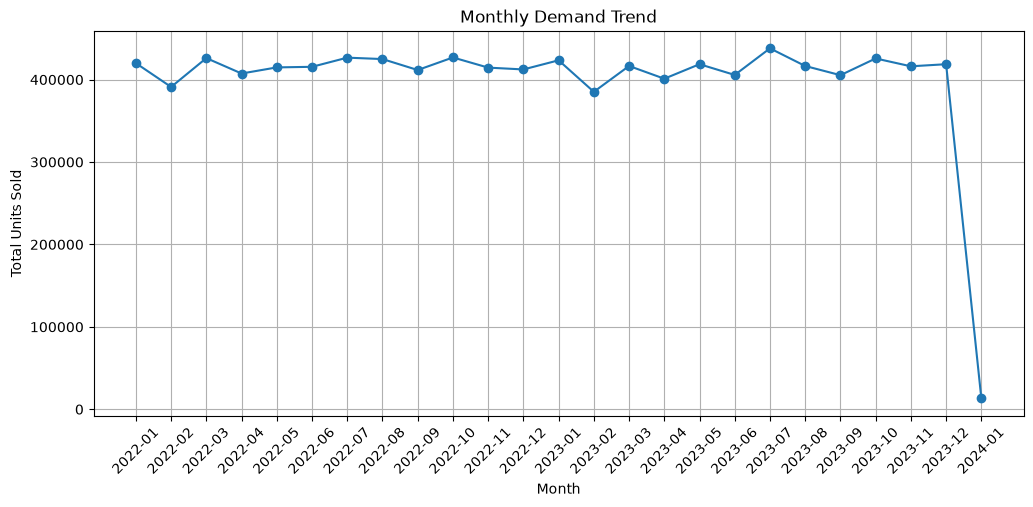

In [16]:
monthly_demand["period"] = (
    monthly_demand["year"].astype(str)
    + "-"
    + monthly_demand["month"].astype(str).str.zfill(2)
)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_demand["period"],
    monthly_demand["units_sold"],
    marker="o"
)

plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Monthly Seasonality

In [17]:
seasonality = (
    sales[sales["date"] < "2024-01-01"]
    .groupby("month")["units_sold"]
    .mean()
    .sort_index()
)

seasonality

month
1     136.023548
2     138.610714
3     135.902419
4     134.742833
5     134.430968
6     136.858333
7     139.443065
8     135.712419
9     136.161833
10    137.501452
11    138.443500
12    134.031129
Name: units_sold, dtype: float64

## Monthly Seasonality Plot

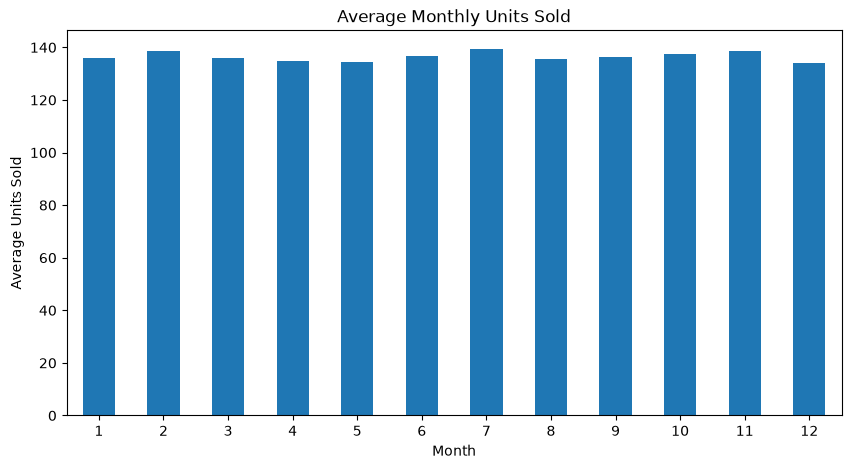

In [18]:
plt.figure(figsize=(10, 5))

seasonality.plot(kind="bar")

plt.title("Average Monthly Units Sold")
plt.xlabel("Month")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=0)
plt.show()

## Promotion Effect on Demand

Compare average demand between promotional and non-promotional periods.

In [19]:
promo_demand = (
    sales.groupby("promo_flag")["units_sold"]
    .agg(["mean", "sum", "count"])
    .reset_index()
)

promo_demand

,promo_flag,mean,sum,count
0,0,136.505375,5016163,36747
1,1,136.423926,4959419,36353


## Promotion Demand Comparison

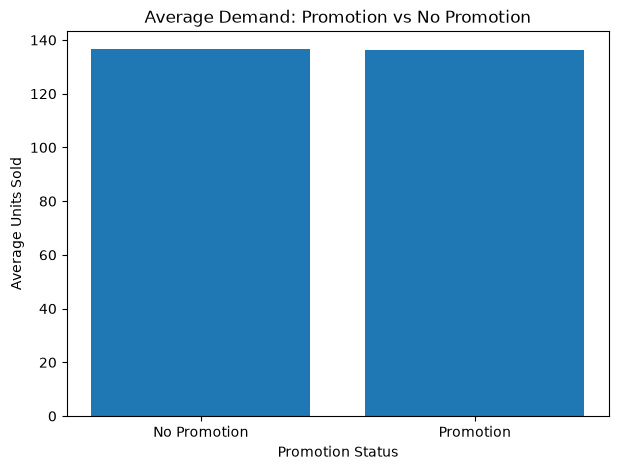

In [20]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["No Promotion", "Promotion"],
    promo_demand["mean"]
)

plt.title("Average Demand: Promotion vs No Promotion")
plt.xlabel("Promotion Status")
plt.ylabel("Average Units Sold")
plt.show()

## Weekly Demand Pattern

In [21]:
weekly_demand = (
    sales.groupby(sales["date"].dt.dayofweek)["units_sold"]
    .mean()
)

weekly_demand.index = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekly_demand

Monday       135.094667
Tuesday      137.307692
Wednesday    136.615096
Thursday     137.281923
Friday       136.851442
Saturday     135.314476
Sunday       136.809714
Name: units_sold, dtype: float64

## Weekly Demand Plot

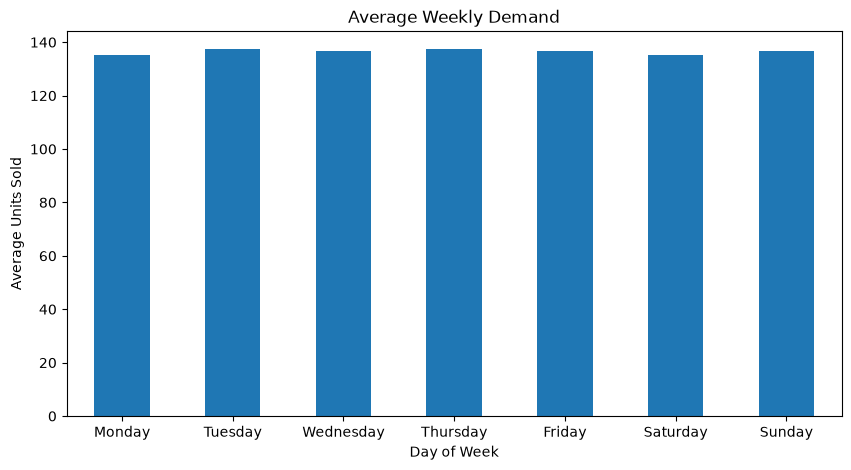

In [22]:
plt.figure(figsize=(10, 5))

weekly_demand.plot(kind="bar")

plt.title("Average Weekly Demand")
plt.xlabel("Day of Week")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=0)
plt.show()

## Category Consistency Check

In [23]:
raw = pd.read_csv("../data/raw/retail_store_inventory.csv")

category_check = (
    raw.groupby("Product ID")["Category"]
    .nunique()
    .sort_values(ascending=False)
)

category_check.head(10)

Product ID
P0001    5
P0002    5
P0003    5
P0004    5
P0005    5
P0006    5
P0007    5
P0008    5
P0009    5
P0010    5
Name: Category, dtype: int64

## Category-wise Demand

In [24]:
category_demand = (
    raw.groupby("Category")["Units Sold"]
    .agg(["mean", "sum", "count"])
    .sort_values("mean", ascending=False)
)

category_demand

,mean,sum,count
Category,,,
Furniture,137.765630,2025017,14699
Groceries,136.916159,2000482,14611
Clothing,136.685765,1999166,14626
Toys,135.934235,1990485,14643
Electronics,135.006680,1960432,14521


## Category-wise Demand Plot

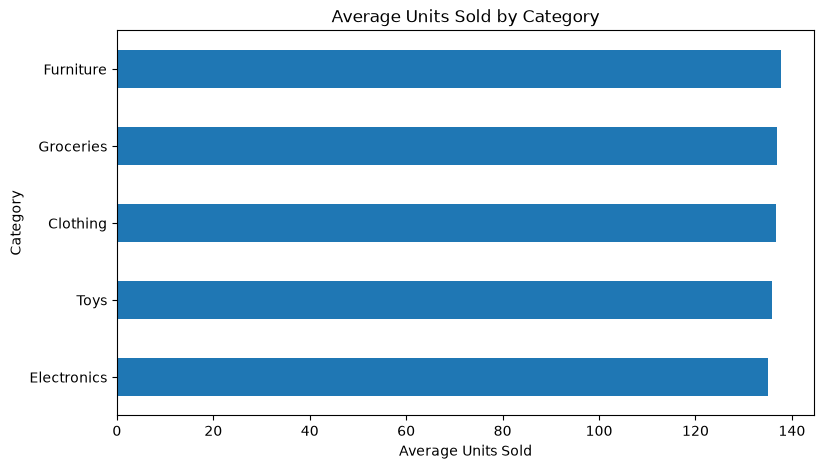

In [25]:
plt.figure(figsize=(9, 5))

category_demand["mean"].sort_values().plot(kind="barh")

plt.title("Average Units Sold by Category")
plt.xlabel("Average Units Sold")
plt.ylabel("Category")
plt.show()

## Weather-wise Demand

In [26]:
weather_demand = (
    raw.groupby("Weather Condition")["Units Sold"]
    .agg(["mean", "sum", "count"])
    .sort_values("mean", ascending=False)
)

weather_demand

,mean,sum,count
Weather Condition,,,
Sunny,138.028650,2524544,18290
Cloudy,136.758324,2497207,18260
Snowy,135.911559,2483376,18272
Rainy,135.160028,2470455,18278


## Weather-wise Demand Plot

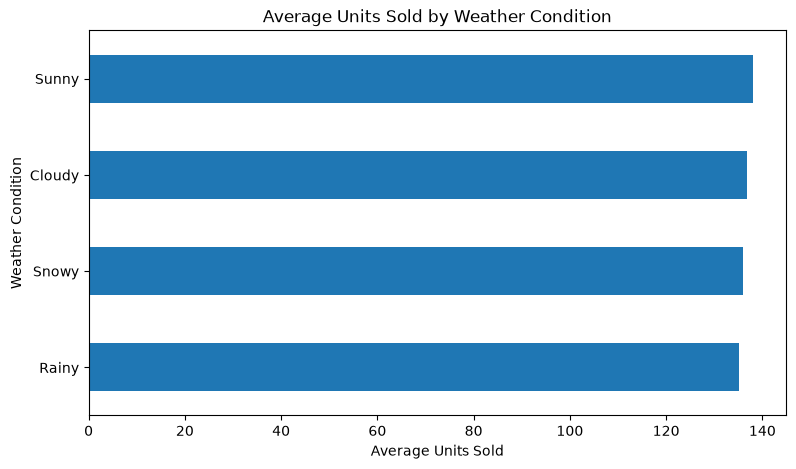

In [27]:
plt.figure(figsize=(9, 5))

weather_demand["mean"].sort_values().plot(kind="barh")

plt.title("Average Units Sold by Weather Condition")
plt.xlabel("Average Units Sold")
plt.ylabel("Weather Condition")
plt.show()

## Seasonality-wise Demand

In [28]:
season_demand = (
    raw.groupby("Seasonality")["Units Sold"]
    .agg(["mean", "sum", "count"])
    .sort_values("mean", ascending=False)
)

season_demand

,mean,sum,count
Seasonality,,,
Autumn,137.782444,2506676,18193
Winter,136.830790,2501951,18285
Spring,135.826828,2487940,18317
Summer,135.428298,2479015,18305


## Seasonality Demand Plot

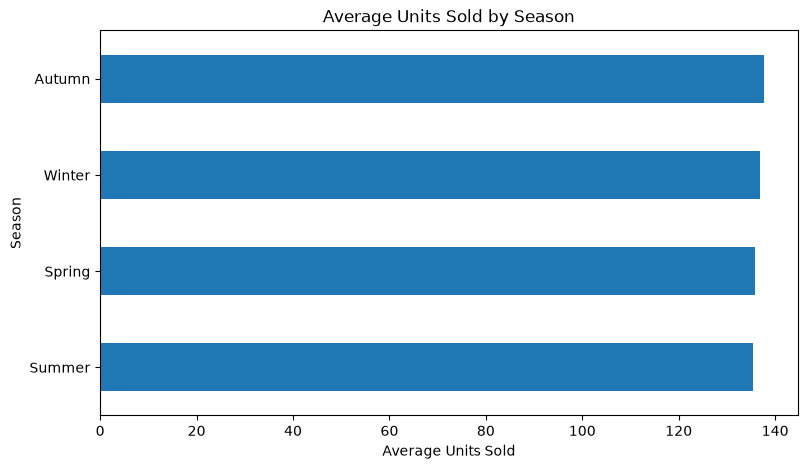

In [29]:
plt.figure(figsize=(9, 5))

season_demand["mean"].sort_values().plot(kind="barh")

plt.title("Average Units Sold by Season")
plt.xlabel("Average Units Sold")
plt.ylabel("Season")
plt.show()

## EDA Business Insights

- Demand is right-skewed with most observations concentrated at lower demand levels.
- Top 10 SKUs contribute around 10.61% of total units sold.
- Promotion and non-promotion average demand is almost the same.
- Weekly demand shows only small variation across days.
- Seasonal demand varies moderately, with Autumn showing the highest average demand.
- No SKU has zero total sales, but 97 SKUs have at least one zero-sales day.

# Feature Engineering

## Prepare Data for Feature Engineering

In [30]:
sales = sales.sort_values(["sku_id", "date"]).reset_index(drop=True)

sales[["date", "sku_id", "units_sold"]].head(10)

,date,sku_id,units_sold
0,2022-01-01,S001_P0001,127
1,2022-01-02,S001_P0001,81
2,2022-01-03,S001_P0001,5
3,2022-01-04,S001_P0001,58
4,2022-01-05,S001_P0001,147
5,2022-01-06,S001_P0001,37
6,2022-01-07,S001_P0001,107
7,2022-01-08,S001_P0001,2
8,2022-01-09,S001_P0001,350
9,2022-01-10,S001_P0001,36


## Lag Features

In [31]:
sales["lag_1"] = (
    sales.groupby("sku_id")["units_sold"]
    .shift(1)
)

sales["lag_7"] = (
    sales.groupby("sku_id")["units_sold"]
    .shift(7)
)

sales["lag_14"] = (
    sales.groupby("sku_id")["units_sold"]
    .shift(14)
)

sales[[
    "date",
    "sku_id",
    "units_sold",
    "lag_1",
    "lag_7",
    "lag_14"
]].head(20)

,date,sku_id,units_sold,lag_1,lag_7,lag_14
0,2022-01-01,S001_P0001,127,NaN,NaN,NaN
1,2022-01-02,S001_P0001,81,127.0,NaN,NaN
2,2022-01-03,S001_P0001,5,81.0,NaN,NaN
3,2022-01-04,S001_P0001,58,5.0,NaN,NaN
4,2022-01-05,S001_P0001,147,58.0,NaN,NaN
5,2022-01-06,S001_P0001,37,147.0,NaN,NaN
6,2022-01-07,S001_P0001,107,37.0,NaN,NaN
7,2022-01-08,S001_P0001,2,107.0,127.0,NaN
8,2022-01-09,S001_P0001,350,2.0,81.0,NaN
9,2022-01-10,S001_P0001,36,350.0,5.0,NaN


## Rolling Demand Features

In [32]:
sales["rolling_mean_7"] = (
    sales.groupby("sku_id")["units_sold"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

sales["rolling_mean_14"] = (
    sales.groupby("sku_id")["units_sold"]
    .transform(lambda x: x.shift(1).rolling(14).mean())
)

sales["rolling_std_7"] = (
    sales.groupby("sku_id")["units_sold"]
    .transform(lambda x: x.shift(1).rolling(7).std())
)

sales[[
    "date",
    "sku_id",
    "units_sold",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_std_7"
]].head(20)

,date,sku_id,units_sold,rolling_mean_7,rolling_mean_14,rolling_std_7
0,2022-01-01,S001_P0001,127,NaN,NaN,NaN
1,2022-01-02,S001_P0001,81,NaN,NaN,NaN
2,2022-01-03,S001_P0001,5,NaN,NaN,NaN
3,2022-01-04,S001_P0001,58,NaN,NaN,NaN
4,2022-01-05,S001_P0001,147,NaN,NaN,NaN
5,2022-01-06,S001_P0001,37,NaN,NaN,NaN
6,2022-01-07,S001_P0001,107,NaN,NaN,NaN
7,2022-01-08,S001_P0001,2,80.285714,NaN,50.638307
8,2022-01-09,S001_P0001,350,62.428571,NaN,53.384945
9,2022-01-10,S001_P0001,36,100.857143,NaN,121.870736


## Calendar Features

In [33]:
sales["week"] = sales["date"].dt.isocalendar().week.astype(int)
sales["month"] = sales["date"].dt.month
sales["day_of_week"] = sales["date"].dt.dayofweek

sales[[
    "date",
    "week",
    "month",
    "day_of_week"
]].head(10)

,date,week,month,day_of_week
0,2022-01-01,52,1,5
1,2022-01-02,52,1,6
2,2022-01-03,1,1,0
3,2022-01-04,1,1,1
4,2022-01-05,1,1,2
5,2022-01-06,1,1,3
6,2022-01-07,1,1,4
7,2022-01-08,1,1,5
8,2022-01-09,1,1,6
9,2022-01-10,2,1,0


## Promotion Feature
Convert the promotion flag into an integer feature for the forecasting model.

In [34]:
sales["promo_flag"] = sales["promo_flag"].astype(int)

sales[[
    "date",
    "sku_id",
    "promo_flag"
]].head(10)

,date,sku_id,promo_flag
0,2022-01-01,S001_P0001,0
1,2022-01-02,S001_P0001,0
2,2022-01-03,S001_P0001,0
3,2022-01-04,S001_P0001,1
4,2022-01-05,S001_P0001,1
5,2022-01-06,S001_P0001,0
6,2022-01-07,S001_P0001,1
7,2022-01-08,S001_P0001,1
8,2022-01-09,S001_P0001,1
9,2022-01-10,S001_P0001,1


## Final Feature Check

Review the engineered features before moving to the forecasting baseline.

In [35]:
feature_cols = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_std_7",
    "week",
    "month",
    "day_of_week",
    "promo_flag"
]

sales[feature_cols].info()

<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   lag_1            73000 non-null  float64
 1   lag_7            72400 non-null  float64
 2   lag_14           71700 non-null  float64
 3   rolling_mean_7   72400 non-null  float64
 4   rolling_mean_14  71700 non-null  float64
 5   rolling_std_7    72400 non-null  float64
 6   week             73100 non-null  int64  
 7   month            73100 non-null  int32  
 8   day_of_week      73100 non-null  int32  
 9   promo_flag       73100 non-null  int64  
dtypes: float64(6), int32(2), int64(2)
memory usage: 5.0 MB


## Weekly Demand Dataset

Aggregate daily sales into weekly SKU-level demand for forecasting.

In [36]:
sales["week_start"] = (
    sales["date"]
    - pd.to_timedelta(sales["date"].dt.dayofweek, unit="D")
)

weekly_sales = (
    sales.groupby(["week_start", "sku_id"])["units_sold"]
    .sum()
    .reset_index()
)

weekly_sales.head(10)

,week_start,sku_id,units_sold
0,2021-12-27,S001_P0001,208
1,2021-12-27,S001_P0002,313
2,2021-12-27,S001_P0003,529
3,2021-12-27,S001_P0004,177
4,2021-12-27,S001_P0005,214
5,2021-12-27,S001_P0006,186
6,2021-12-27,S001_P0007,153
7,2021-12-27,S001_P0008,386
8,2021-12-27,S001_P0009,229
9,2021-12-27,S001_P0010,67


## Weekly Dataset Check

Check the size and date range of the weekly forecasting dataset.

In [37]:
print("Weekly dataset shape:", weekly_sales.shape)
print("First week:", weekly_sales["week_start"].min())
print("Last week:", weekly_sales["week_start"].max())
print("Unique SKUs:", weekly_sales["sku_id"].nunique())

Weekly dataset shape: (10600, 3)
First week: 2021-12-27 00:00:00
Last week: 2024-01-01 00:00:00
Unique SKUs: 100


## Complete Weekly Dataset

Keep only complete weeks for reliable weekly forecasting.

In [38]:
weekly_sales = weekly_sales[
    (weekly_sales["week_start"] >= "2022-01-03")
    & (weekly_sales["week_start"] <= "2023-12-25")
].reset_index(drop=True)

print("Weekly dataset shape:", weekly_sales.shape)
print("First week:", weekly_sales["week_start"].min())
print("Last week:", weekly_sales["week_start"].max())

Weekly dataset shape: (10400, 3)
First week: 2022-01-03 00:00:00
Last week: 2023-12-25 00:00:00


## Seasonal Naive Lag

Use the previous year's demand for the same SKU as the baseline forecast.

In [39]:
weekly_sales = weekly_sales.sort_values(
    ["sku_id", "week_start"]
).reset_index(drop=True)

weekly_sales["seasonal_naive"] = (
    weekly_sales.groupby("sku_id")["units_sold"]
    .shift(52)
)

weekly_sales[
    ["week_start", "sku_id", "units_sold", "seasonal_naive"]
].head(60)

,week_start,sku_id,units_sold,seasonal_naive
0,2022-01-03,S001_P0001,706,NaN
1,2022-01-10,S001_P0001,686,NaN
2,2022-01-17,S001_P0001,1142,NaN
3,2022-01-24,S001_P0001,685,NaN
4,2022-01-31,S001_P0001,1032,NaN
5,2022-02-07,S001_P0001,708,NaN
6,2022-02-14,S001_P0001,994,NaN
7,2022-02-21,S001_P0001,1222,NaN
8,2022-02-28,S001_P0001,1259,NaN
9,2022-03-07,S001_P0001,983,NaN


## Baseline Evaluation Dataset

Use the weeks with available seasonal-naive predictions for baseline evaluation.

In [40]:
baseline_data = weekly_sales.dropna(
    subset=["seasonal_naive"]
).copy()

print("Baseline evaluation shape:", baseline_data.shape)
print("First evaluation week:", baseline_data["week_start"].min())
print("Last evaluation week:", baseline_data["week_start"].max())

Baseline evaluation shape: (5200, 4)
First evaluation week: 2023-01-02 00:00:00
Last evaluation week: 2023-12-25 00:00:00


## WAPE Metric

Calculate WAPE to evaluate the seasonal-naive baseline forecast.

In [41]:
actual = baseline_data["units_sold"]
forecast = baseline_data["seasonal_naive"]

wape = (
    (actual - forecast).abs().sum()
    / actual.abs().sum()
) * 100

print("Baseline WAPE:", round(wape, 2), "%")

Baseline WAPE: 33.71 %


## Baseline Summary

The seasonal-naive baseline gives a WAPE of 33.71% on the 2023 evaluation period.

In [42]:
print("Seasonal-Naive Baseline")
print("-----------------------")
print("Evaluation period:", baseline_data["week_start"].min().date(),
      "to", baseline_data["week_start"].max().date())
print("Evaluation rows:", len(baseline_data))
print("WAPE:", round(wape, 2), "%")

Seasonal-Naive Baseline
-----------------------
Evaluation period: 2023-01-02 to 2023-12-25
Evaluation rows: 5200
WAPE: 33.71 %


## Baseline Results

Save the seasonal-naive baseline results for the project checkpoint.

In [43]:
baseline_results = pd.DataFrame({
    "metric": ["WAPE"],
    "value": [round(wape, 2)],
    "evaluation_start": [baseline_data["week_start"].min().date()],
    "evaluation_end": [baseline_data["week_start"].max().date()],
    "evaluation_rows": [len(baseline_data)]
})

baseline_results

,metric,value,evaluation_start,evaluation_end,evaluation_rows
0,WAPE,33.71,2023-01-02,2023-12-25,5200


## Baseline Forecast Sample

Compare actual weekly demand with the seasonal-naive forecast for a few observations.

In [44]:
baseline_data[
    ["week_start", "sku_id", "units_sold", "seasonal_naive"]
].head(10)

,week_start,sku_id,units_sold,seasonal_naive
52,2023-01-02,S001_P0001,826,706.0
53,2023-01-09,S001_P0001,874,686.0
54,2023-01-16,S001_P0001,769,1142.0
55,2023-01-23,S001_P0001,1061,685.0
56,2023-01-30,S001_P0001,725,1032.0
57,2023-02-06,S001_P0001,1560,708.0
58,2023-02-13,S001_P0001,1148,994.0
59,2023-02-20,S001_P0001,886,1222.0
60,2023-02-27,S001_P0001,1119,1259.0
61,2023-03-06,S001_P0001,1358,983.0


## Actual vs Baseline Forecast

Visualize actual demand against the seasonal-naive baseline for one SKU.

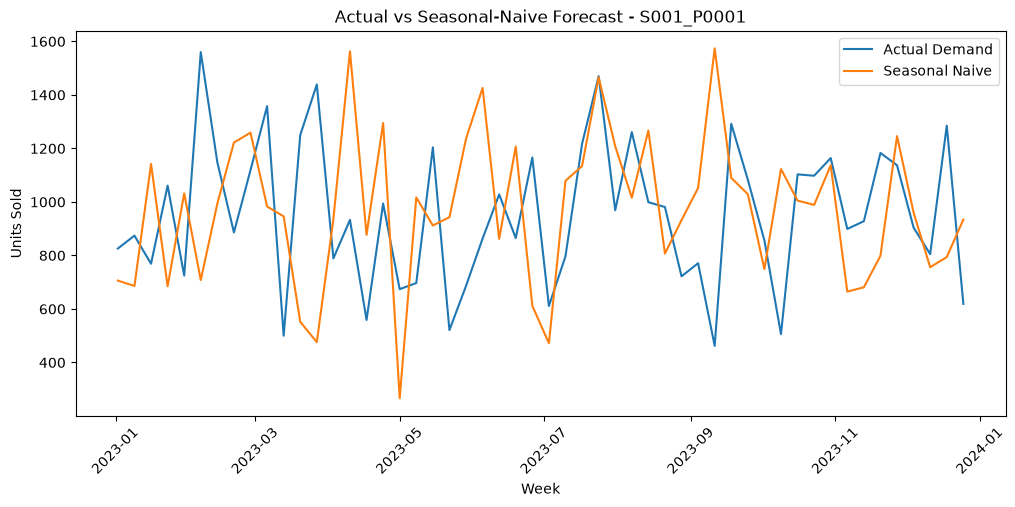

In [45]:
sku_sample = "S001_P0001"

plot_data = baseline_data[
    baseline_data["sku_id"] == sku_sample
]

plt.figure(figsize=(12, 5))

plt.plot(
    plot_data["week_start"],
    plot_data["units_sold"],
    label="Actual Demand"
)

plt.plot(
    plot_data["week_start"],
    plot_data["seasonal_naive"],
    label="Seasonal Naive"
)

plt.title(f"Actual vs Seasonal-Naive Forecast - {sku_sample}")
plt.xlabel("Week")
plt.ylabel("Units Sold")
plt.legend()
plt.xticks(rotation=45)
plt.show()

## EDA Insight Memo

Summarize the main demand patterns, SKU behavior, drivers, engineered features, and baseline result.

In [46]:
eda_memo = {
    "total_records": len(sales),
    "total_skus": sales["sku_id"].nunique(),
    "zero_sales_records": zero_sales,
    "zero_sales_percentage": round(
        zero_sales / total_sales_records * 100, 2
    ),
    "top_10_contribution": round(contribution, 2),
    "baseline_wape": round(wape, 2),
    "evaluation_rows": len(baseline_data)
}

eda_memo

{'total_records': 73100,
 'total_skus': 100,
 'zero_sales_records': np.int64(360),
 'zero_sales_percentage': np.float64(0.49),
 'top_10_contribution': np.float64(10.61),
 'baseline_wape': np.float64(33.71),
 'evaluation_rows': 5200}

# EDA Insight Memo

The dataset contains 100 SKUs across 73,100 daily records.

Demand is right-skewed, and the top 10 SKUs contribute 10.61% of total units sold. There are 360 zero-sales records, representing 0.49% of all records.

Promotion and non-promotion periods show very similar average demand. Weekly demand also shows only small variation across days, while seasonal demand varies moderately.

Lag, rolling, calendar, and promotion features were engineered for forecasting.

The seasonal-naive baseline uses the previous year's same-week demand and achieves a WAPE of 33.71% on the 2023 evaluation period.

In [47]:
memo_path = "../reports/eda_insight_memo.md"

with open(memo_path, "w", encoding="utf-8") as f:
    f.write("""# EDA Insight Memo

The dataset contains 100 SKUs across 73,100 daily records.

Demand is right-skewed, and the top 10 SKUs contribute 10.61% of total units sold. There are 360 zero-sales records, representing 0.49% of all records.

Promotion and non-promotion periods show very similar average demand. Weekly demand also shows only small variation across days, while seasonal demand varies moderately.

Lag, rolling, calendar, and promotion features were engineered for forecasting.

The seasonal-naive baseline uses the previous year's same-week demand and achieves a WAPE of 33.71% on the 2023 evaluation period.
""")

print("EDA insight memo saved:", memo_path)

EDA insight memo saved: ../reports/eda_insight_memo.md


## Baseline Result

Save the seasonal-naive baseline metric and evaluation details for the project checkpoint.

In [48]:
baseline_results.to_csv(
    "../reports/baseline_results.csv",
    index=False
)

print("Baseline results saved: ../reports/baseline_results.csv")

Baseline results saved: ../reports/baseline_results.csv


## Weekly Forecasting Dataset

Save the prepared weekly SKU-level demand data for the next forecasting stage.

In [49]:
weekly_sales.to_csv(
    "../data/processed/weekly_sales.csv",
    index=False
)

print("Weekly forecasting dataset saved: ../data/processed/weekly_sales.csv")
print("Shape:", weekly_sales.shape)

Weekly forecasting dataset saved: ../data/processed/weekly_sales.csv
Shape: (10400, 4)


## Week 2 Checkpoint Summary

EDA, feature engineering, and the seasonal-naive baseline are complete.

The baseline uses previous-year same-week demand and achieves a WAPE of 33.71% for the 2023 evaluation period.

In [50]:
print("WEEK 2 CHECKPOINT")
print("=================")
print("EDA records:", len(sales))
print("Unique SKUs:", sales["sku_id"].nunique())
print("Weekly records:", len(weekly_sales))
print("Baseline WAPE:", round(wape, 2), "%")
print("EDA memo: Saved")
print("Baseline results: Saved")
print("Weekly dataset: Saved")

WEEK 2 CHECKPOINT
EDA records: 73100
Unique SKUs: 100
Weekly records: 10400
Baseline WAPE: 33.71 %
EDA memo: Saved
Baseline results: Saved
Weekly dataset: Saved
